# TP 2.3 – Classification automatique de réclamations clients bancaires (NLP)

**ECE – ING Data & IA – Natural Language Processing**

| | |
|---|---|
| **Cas d'usage** | Routage automatique des réclamations clients vers le bon service (secteur bancaire / financier) |
| **Tâche NLP** | Classification supervisée **multi-classes** de textes libres |
| **Jeu de données** | *US Consumer Finance Complaints* – CFPB (Kaggle : `cfpb/us-consumer-finance-complaints`) |
| **Modèles** | Naive Bayes multinomial (baseline), **SVM linéaire** (modèle principal), Régression logistique (bonus / comparaison) |
| **Métrique principale** | F1 macro (classes déséquilibrées) |

## Sommaire
0. Introduction : contexte, cas d'usage et jeu de données
1. Brève revue de littérature
2. Chargement et exploration des données
3. Nettoyage et préparation
4. Vectorisation TF-IDF
5. Modélisation (Naive Bayes, SVM linéaire, Régression logistique)
6. Évaluation et interprétation
7. Conclusion

## 0. Introduction

### 0.1 Contexte
Les établissements financiers reçoivent chaque jour des milliers de **réclamations rédigées librement** par leurs
clients (formulaires web, e-mails). Chaque réclamation doit être transmise au **service compétent** : cartes
bancaires, crédits immobiliers, recouvrement de dettes, rapports de crédit, etc. Ce tri est souvent fait à la
main : il est lent, coûteux et sujet aux erreurs, ce qui retarde la réponse au client (et, aux États-Unis, peut
exposer l'établissement à des sanctions du régulateur).

### 0.2 Cas d'usage
**Objectif :** à partir du **texte de la réclamation uniquement**, prédire automatiquement la **catégorie de
produit financier** concernée, afin d'**aiguiller** la réclamation vers le bon service.

Pourquoi ce cas d'usage ?
- **Valeur métier claire** : gain de temps et réduction des erreurs d'aiguillage ; les métriques (rappel par
  classe, confusions) se traduisent directement en « réclamations mal routées ».
- **Données réelles, publiques et volumineuses** : de vraies plaintes de consommateurs américains, publiées par
  une agence fédérale (domaine public).
- **Différent des TP 2.1 / 2.2** : il ne s'agit pas d'analyse de sentiment binaire mais d'une classification
  **thématique multi-classes** sur des textes **longs** et **bruités** (anonymisation, fautes, styles variés).
- **Interprétable** : un modèle linéaire sur TF-IDF permet d'identifier les mots qui caractérisent chaque service.

### 0.3 Jeu de données
- **Source :** *Consumer Complaint Database* du **CFPB** (Consumer Financial Protection Bureau), version publiée
  sur Kaggle par le CFPB : <https://www.kaggle.com/datasets/cfpb/us-consumer-finance-complaints>
  (fichier `consumer_complaints.csv`, réclamations de 2011 à 2016).
- **Licence :** données publiques du gouvernement américain.
- **Colonnes utilisées :**
  - `consumer_complaint_narrative` → **texte d'entrée** (récit libre du client, anonymisé par le CFPB avec des `XXXX`) ;
  - `product` → **variable cible** (catégorie de produit) ;
  - `sub_product`, `issue`, `date_received` → uniquement pour l'exploration.
- **Classes :** 11 produits dans cette version (*Virtual currency*, présent dans la base complète du CFPB, n'y figure pas).
- **Particularité :** le récit n'est publié que si le client y a consenti (à partir de 2015) : une grande partie
  des lignes n'a **pas de texte** et devra être écartée.

## 1. Brève revue de littérature

**Prétraitement et nettoyage.** Les textes bruts contiennent du bruit (ponctuation, chiffres, majuscules, balises,
masques d'anonymisation). On normalise généralement en minuscules, on supprime les caractères non informatifs et
les **mots vides** (*stop words* : « the », « and »…), très fréquents mais peu discriminants.

**Tokenisation.** Découpage du texte en unités (*tokens*) : mots, sous-mots (BPE/WordPiece, utilisés par BERT) ou
caractères. Pour des modèles « sac de mots », la tokenisation **au niveau des mots** est la plus courante.

**Normalisation morphologique.** Le *stemming* (Porter) coupe les suffixes de façon heuristique (« charged » → « charg ») ;
la **lemmatisation** (WordNet) ramène chaque mot à sa forme de dictionnaire (« charges » → « charge »). La
lemmatisation est plus lente mais produit des tokens lisibles, utiles pour l'interprétation.

**Représentations vectorielles.**
- *Bag-of-Words* : compte des occurrences de chaque mot ; ignore l'ordre des mots.
- **TF-IDF** (*Term Frequency – Inverse Document Frequency*) : pondère chaque terme par sa fréquence dans le document
  et par sa rareté dans le corpus ; les termes spécifiques à un document/une classe ressortent. Les **n-grammes**
  (ex. bigrammes « credit report ») capturent un peu de contexte local.
- *Word embeddings* (Word2Vec – Mikolov et al., 2013 ; GloVe – Pennington et al., 2014) : vecteurs denses appris
  tels que des mots de sens proche soient proches dans l'espace.
- *Embeddings contextuels* (BERT – Devlin et al., 2019) : le vecteur d'un mot dépend de la phrase grâce à
  l'auto-attention des **Transformers**.

**Modèles de classification.**
- **Naive Bayes multinomial** : modèle probabiliste supposant l'indépendance des mots sachant la classe ; très
  rapide, baseline classique pour le texte (détection de spam).
- **SVM linéaire** : cherche l'hyperplan séparant les classes avec la plus grande marge ; reconnu comme l'un des
  meilleurs classifieurs pour des représentations TF-IDF de grande dimension et creuses (Joachims, 1998).
- **Régression logistique** : modèle linéaire probabiliste, performances proches du SVM, fournit des probabilités.
- **Deep learning** (RNN/LSTM, CNN, Transformers) : capturent l'ordre et le contexte, souvent meilleurs sur des
  tâches sémantiques fines, mais demandent plus de données, de calcul (GPU) et sont moins interprétables.

**Choix pour ce TP.** Nos textes sont longs, riches en **vocabulaire spécifique** à chaque produit (« foreclosure »,
« escrow », « collection agency », « credit report »…) et nous disposons de dizaines de milliers d'exemples :
c'est le cas typique où **TF-IDF + SVM linéaire** est très performant, rapide à entraîner sur CPU et interprétable.
Le Naive Bayes sert de point de comparaison simple et la régression logistique de second modèle (bonus).

## 2. Chargement et exploration des données

### 2.1 Imports et paramètres
On fixe une graine aléatoire (`RANDOM_STATE`) pour que les résultats soient **reproductibles** (échantillonnage,
découpage train/test, validation croisée).

In [1]:
import os
import re
import time
import warnings
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import RegexpTokenizer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42          # graine pour la reproductibilité
MAX_DOCS = 50_000          # taille max. de l'échantillon de travail (temps de calcul raisonnable sur CPU)
TEST_SIZE = 0.20           # 80 % entraînement / 20 % test
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

### 2.2 Chargement du jeu de données
Le fichier `consumer_complaints.csv` est recherché dans `data/`. S'il est absent, il est téléchargé
automatiquement depuis Kaggle avec `kagglehub` (le jeu est public). On le télécharge aussi manuellement depuis
la page Kaggle et on le place dans `data/`.

In [2]:
def locate_dataset():
    # 1) chemin explicite (variable d'environnement), 2) dossier data/, 3) téléchargement Kaggle
    env_path = os.environ.get("TP23_DATA")
    if env_path:
        return Path(env_path)
    local = DATA_DIR / "consumer_complaints.csv"
    if local.exists():
        return local
    import kagglehub
    folder = Path(kagglehub.dataset_download("kaggle/us-consumer-finance-complaints"))
    return next(folder.rglob("consumer_complaints.csv"))


DATA_PATH = locate_dataset()
print("Fichier utilisé :", DATA_PATH)

# Lecture : low_memory=False évite des types mixtes ; on essaie UTF-8 puis latin-1 par sécurité.
try:
    raw = pd.read_csv(DATA_PATH, low_memory=False)
except UnicodeDecodeError:
    raw = pd.read_csv(DATA_PATH, low_memory=False, encoding="latin-1")

print("Dimensions :", raw.shape)
raw.head(3)

Fichier utilisé : /Users/justin/.cache/kagglehub/datasets/kaggle/us-consumer-finance-complaints/versions/2/consumer_complaints.csv
Dimensions : (555957, 18)


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473


**Explication.** Chaque ligne est une réclamation. Les colonnes décrivent la réclamation (produit, sous-produit,
problème, texte libre), l'entreprise visée et le suivi (réponse de l'entreprise, délai…). Seuls le **texte**
(`consumer_complaint_narrative`) et la **cible** (`product`) servent au modèle : les autres colonnes, comme
`issue` ou `company_response_to_consumer`, ne seraient pas connues au moment de la réception d'une nouvelle
réclamation (ou rendraient la tâche triviale) et créeraient une **fuite d'information**.

In [3]:
# Types des colonnes et taux de valeurs manquantes
info = pd.DataFrame({
    "type": raw.dtypes.astype(str),
    "nb_manquants": raw.isna().sum(),
    "%_manquants": (raw.isna().mean() * 100).round(1),
})
info

,type,nb_manquants,%_manquants
date_received,str,0,0.0
product,str,0,0.0
sub_product,str,158322,28.5
issue,str,0,0.0
sub_issue,str,343335,61.8
consumer_complaint_narrative,str,489151,88.0
company_public_response,str,470833,84.7
company,str,0,0.0
state,str,4887,0.9
zipcode,str,4505,0.8


In [4]:
TEXT_COL, TARGET_COL = "consumer_complaint_narrative", "product"

n_total = len(raw)
n_text = raw[TEXT_COL].notna().sum()
print(f"Réclamations totales           : {n_total:,}")
print(f"Réclamations avec texte        : {n_text:,} ({n_text / n_total:.1%})")
print(f"Réclamations sans texte        : {n_total - n_text:,} ({1 - n_text / n_total:.1%})")
print(f"Nombre de produits (classes)   : {raw[TARGET_COL].nunique()}")
if "date_received" in raw.columns:
    dates = pd.to_datetime(raw["date_received"], errors="coerce")
    print(f"Période couverte               : {dates.min():%Y-%m-%d} → {dates.max():%Y-%m-%d}")
    print(f"Premier texte publié le        : {dates[raw[TEXT_COL].notna()].min():%Y-%m-%d}")

Réclamations totales           : 555,957
Réclamations avec texte        : 66,806 (12.0%)
Réclamations sans texte        : 489,151 (88.0%)
Nombre de produits (classes)   : 11
Période couverte               : 2011-12-01 → 2016-04-25
Premier texte publié le        : 2015-03-19


**Interprétation.** Sur 555 957 réclamations, seules **66 806 (12 %) ont un récit** : le CFPB ne publie le texte
que lorsque le client y a consenti, et seulement depuis le **19 mars 2015** (alors que la base commence en
décembre 2011). Les 88 % restants sont inutilisables pour une tâche de NLP et seront supprimés. Il reste
néanmoins près de 67 000 textes, ce qui est largement suffisant pour entraîner un modèle de classification de
texte.

### 2.3 Distribution des classes
On restreint l'exploration aux réclamations **avec texte**, car ce sont les seules utilisées par le modèle.

,nb,%
product,,
Debt collection,17552,26.27
Mortgage,14919,22.33
Credit reporting,12526,18.75
Credit card,7929,11.87
Bank account or service,5711,8.55
Consumer Loan,3678,5.51
Student loan,2128,3.19
Prepaid card,861,1.29
Payday loan,726,1.09


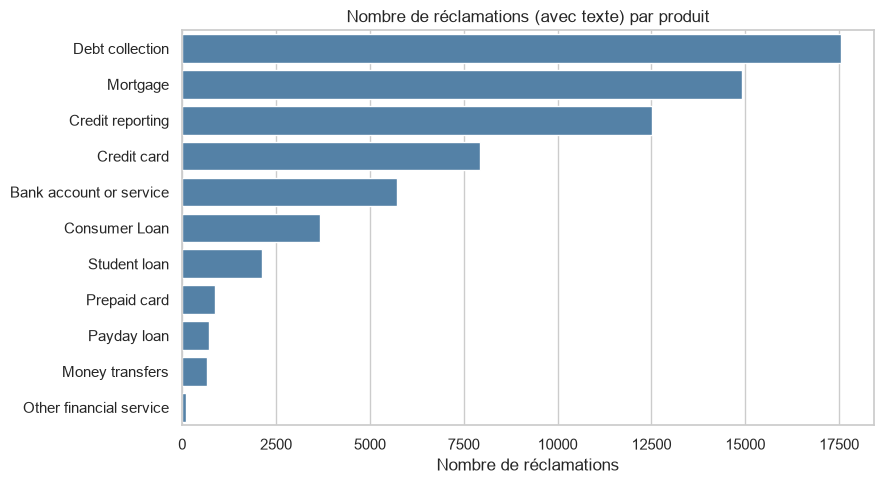

Rapport classe majoritaire / classe minoritaire : 160x


In [5]:
df = raw.loc[raw[TEXT_COL].notna(), [TEXT_COL, TARGET_COL, "sub_product", "issue", "date_received"]].copy()
df = df.rename(columns={TEXT_COL: "text", TARGET_COL: "product"})

counts = df["product"].value_counts()
display(pd.DataFrame({"nb": counts, "%": (counts / counts.sum() * 100).round(2)}))

plt.figure(figsize=(9, 5))
sns.barplot(x=counts.values, y=counts.index, color="steelblue")
plt.title("Nombre de réclamations (avec texte) par produit")
plt.xlabel("Nombre de réclamations")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(f"Rapport classe majoritaire / classe minoritaire : {counts.max() / counts.min():.0f}x")

**Interprétation.** Les classes sont **fortement déséquilibrées** : *Debt collection*, *Mortgage* et
*Credit reporting* représentent à elles trois **67 %** des réclamations, tandis que *Other financial service*
(110 textes, 0,16 %), *Money transfers*, *Payday loan* et *Prepaid card* (≈ 1 % chacune) sont très rares : la
classe majoritaire est **160 fois** plus fréquente que la minoritaire. Conséquences pour la suite :
1. Des classes avec quelques centaines d'exemples seulement ne peuvent pas être apprises correctement →
   **regroupement** de produits proches (section 3.2).
2. L'**accuracy** seule serait trompeuse (un modèle qui favorise les grandes classes paraîtrait bon) → on utilisera
   le **F1 macro**, qui donne le même poids à chaque classe.
3. Découpage train/test **stratifié** et pondération des classes (`class_weight="balanced"`) dans les modèles.

### 2.4 Longueur des textes

count    66806.0
mean       190.6
std        166.8
min          1.0
25%         71.0
50%        136.0
75%        254.0
max       1284.0
Name: n_words, dtype: float64


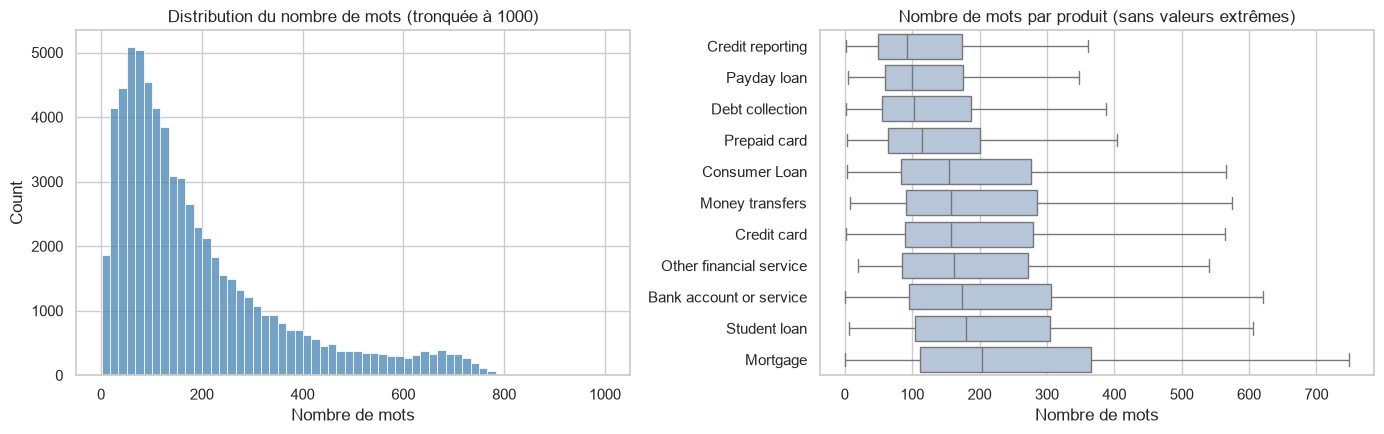

In [6]:
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["n_words"].clip(upper=1000), bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution du nombre de mots (tronquée à 1000)")
axes[0].set_xlabel("Nombre de mots")
order = df.groupby("product")["n_words"].median().sort_values().index
sns.boxplot(data=df, y="product", x="n_words", order=order, showfliers=False, ax=axes[1], color="lightsteelblue")
axes[1].set_title("Nombre de mots par produit (sans valeurs extrêmes)")
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

**Interprétation.** Les réclamations sont des **textes longs** : 136 mots en médiane, 191 en moyenne, et une
distribution asymétrique à droite (25 % des textes dépassent 254 mots, le plus long en compte 1 284 ; le CFPB
limite la saisie). Des textes longs contiennent beaucoup d'indices lexicaux, ce qui favorise les approches
« sac de mots » (TF-IDF). L'option `sublinear_tf=True` du TF-IDF (log de la fréquence) limitera l'influence des
mots répétés dans les textes très longs. Quelques textes ne contiennent qu'un ou deux mots (minimum = 1) : ils
seront supprimés. Les longueurs médianes sont assez proches d'un produit à l'autre : la longueur n'est pas, à
elle seule, un critère discriminant.

### 2.5 Aperçu des textes et du bruit

In [7]:
for _, row in df.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"[{row['product']}]\n{row['text'][:500]}...\n")

# Mesure du bruit d'anonymisation : proportion de textes contenant des masques XXXX ou des montants {$...}
print(f"Textes contenant 'XXXX'     : {df['text'].str.contains('XX', regex=False).mean():.1%}")
has_amount = df["text"].str.contains("{$", regex=False).mean()
print(f"Textes contenant un montant : {has_amount:.1%}")

[Debt collection]
I have been battling with portfolio recovery and Foster, Garbus & Garbus for over a year regarding a debt that is not mine. I continue receiving letters from Foster, Garbus XXXX Garbus regarding same debt although I 've submitted documents to Foster, Garbus & Garbus proving that I DO NOT OWE said debt. These guys went as far as having my XXXX XXXX account frozen last year and I thought the issue was resolved once I submitted my documents. 
...

[Mortgage]
In the fall of XXXX I applied for a mortgage modification from XXXX XXXX XXXX. I was laid off XXXX XXXX of that year and decided to just retire. After over a year and a half I finally received the signed documents from XXXX in XXXX of XXXX. It was pure XXXX the entire time working with them. As soon as I received the signed documents XXXX sold my mortgage to GreenTree. GreenTree would not acknowledge that I had a modification and finally in the fall started foreclosure procedures on me. I contin...

[Credit card]
i t

**Interprétation.** Les textes sont rédigés en anglais courant, souvent à la première personne, avec des
fautes et des majuscules aléatoires. Le CFPB a remplacé les informations personnelles (noms, dates, numéros de
compte) par des **masques `XXXX`** et a encadré les montants par des accolades (`{$1500.00}`). Ces masques
apparaissent dans une grande partie des textes : ils n'apportent **aucune information** sur le produit et
devront être supprimés, sinon « xxxx » deviendrait l'un des tokens les plus fréquents du corpus.

### 2.6 Doublons

In [8]:
n_dup = df.duplicated(subset="text").sum()
n_dup_conflict = (df.groupby("text")["product"].nunique() > 1).sum()
print(f"Textes en double                          : {n_dup:,}")
print(f"Textes identiques avec des produits différents : {n_dup_conflict:,}")

Textes en double                          : 1,160
Textes identiques avec des produits différents : 19


**Interprétation.** On trouve **1 160 textes en double** (≈ 1,7 % des récits) : certains clients déposent
plusieurs fois la même réclamation (parfois contre plusieurs entreprises). Garder ces doublons risquerait de
placer le même texte dans le train **et** dans le test, ce qui gonflerait artificiellement les scores : ils seront
supprimés. **19 textes identiques portent des produits différents** : c'est une illustration directe du **bruit
d'étiquetage** (c'est le client qui choisit le produit dans le formulaire).

## 3. Nettoyage et préparation des données

### 3.1 Suppression des lignes inexploitables et des doublons

In [9]:
n0 = len(df)
df = df.dropna(subset=["text", "product"])
df["text"] = df["text"].str.strip()
df = df[df["n_words"] >= 5]                         # textes trop courts : aucun contenu exploitable
df = df.drop_duplicates(subset="text", keep="first")  # évite la fuite train/test
print(f"{n0:,} → {len(df):,} réclamations ({n0 - len(df):,} supprimées)")

66,806 → 65,585 réclamations (1,221 supprimées)


### 3.2 Regroupement des classes
Plusieurs produits ont trop peu d'exemples pour être appris de manière fiable, et certains relèvent en pratique
du **même service** d'une banque. On regroupe donc les 11 produits d'origine en **6 classes métier** :

| Classe finale | Produits d'origine | Justification |
|---|---|---|
| Debt collection | Debt collection | Classe volumineuse, service dédié (recouvrement). |
| Credit reporting | Credit reporting | Classe volumineuse, service dédié (rapports / scores de crédit). |
| Mortgage | Mortgage | Classe volumineuse, vocabulaire très spécifique (crédit immobilier). |
| Card services | Credit card, Prepaid card | Même métier (moyens de paiement par carte) ; *Prepaid card* trop petite seule. |
| Bank account & transfers | Bank account or service, Money transfers, Other financial service | Opérations de banque de détail sur compte (virements, chèques, mandats…). |
| Loans | Consumer Loan, Student loan, Payday loan | Crédits à la consommation au sens large (auto, étudiant, prêt sur salaire). |

*Virtual currency* n'apparaît pas dans cette version du jeu (elle existe dans la base complète du CFPB avec une
poignée de réclamations) ; la table la prévoit quand même et la **supprime**, par robustesse si on change de
version du fichier.

In [10]:
PRODUCT_MAP = {
    "Debt collection": "Debt collection",
    "Credit reporting": "Credit reporting",
    "Mortgage": "Mortgage",
    "Credit card": "Card services",
    "Prepaid card": "Card services",
    "Bank account or service": "Bank account & transfers",
    "Money transfers": "Bank account & transfers",
    "Other financial service": "Bank account & transfers",
    "Consumer Loan": "Loans",
    "Student loan": "Loans",
    "Payday loan": "Loans",
    "Virtual currency": None,   # absente de cette version ; supprimée si présente (trop rare)
}

unknown = set(df["product"]) - set(PRODUCT_MAP)
print("Produits non prévus dans la table :", unknown or "aucun")

df["label"] = df["product"].map(PRODUCT_MAP)
print("Lignes supprimées (produit écarté ou inconnu) :", df["label"].isna().sum())
df = df.dropna(subset=["label"])

pd.crosstab(df["product"], df["label"])

Produits non prévus dans la table : aucun
Lignes supprimées (produit écarté ou inconnu) : 0


label,Bank account & transfers,Card services,Credit reporting,Debt collection,Loans,Mortgage
product,,,,,,
Bank account or service,5685,0,0,0,0,0
Consumer Loan,0,0,0,0,3665,0
Credit card,0,7904,0,0,0,0
Credit reporting,0,0,11843,0,0,0
Debt collection,0,0,0,17108,0,0
Money transfers,665,0,0,0,0,0
Mortgage,0,0,0,0,0,14902
Other financial service,109,0,0,0,0,0
Payday loan,0,0,0,0,726,0


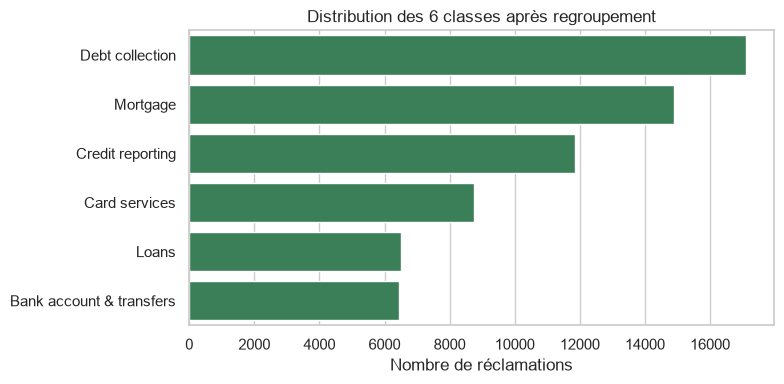

label
Debt collection             26.1 %
Mortgage                    22.7 %
Credit reporting            18.1 %
Card services               13.4 %
Loans                        9.9 %
Bank account & transfers     9.8 %
Name: count, dtype: str

Rapport classe majoritaire / minoritaire : 2.6x


In [11]:
label_counts = df["label"].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=label_counts.values, y=label_counts.index, color="seagreen")
plt.title("Distribution des 6 classes après regroupement")
plt.xlabel("Nombre de réclamations")
plt.ylabel("")
plt.tight_layout()
plt.show()
print((label_counts / label_counts.sum() * 100).round(1).astype(str) + " %")
print(f"\nRapport classe majoritaire / minoritaire : {label_counts.max() / label_counts.min():.1f}x")

**Interprétation.** Après suppression des doublons et des textes trop courts (66 806 → 65 585 réclamations)
et regroupement, le rapport entre la classe majoritaire (*Debt collection*, 26 %) et la minoritaire
(*Bank account & transfers*, 9,8 %) passe de **160× à 2,6×**. **Chaque classe dispose désormais de plus de 6 000
exemples**, ce qui permet un apprentissage fiable. Le déséquilibre résiduel sera traité par la stratification et
la pondération des classes.

### 3.3 Échantillonnage stratifié
Pour garder des temps de calcul raisonnables (validation croisée de plusieurs modèles sur CPU), on limite le
corpus à `MAX_DOCS` réclamations, tirées **en respectant les proportions de chaque classe** (stratification).

In [12]:
if len(df) > MAX_DOCS:
    df, _ = train_test_split(df, train_size=MAX_DOCS, stratify=df["label"], random_state=RANDOM_STATE)
df = df.reset_index(drop=True)
print("Taille du corpus de travail :", len(df))

Taille du corpus de travail : 50000


### 3.4 Nettoyage, tokenisation, stop words et lemmatisation

Étapes appliquées à chaque texte, dans cet ordre :
1. **Minuscules** : « Mortgage » et « mortgage » deviennent le même token.
2. **Suppression des montants** `{$1,500.00}` et des **URL**.
3. **Suppression de tout caractère non alphabétique** (ponctuation, chiffres, `/` des dates masquées).
4. **Suppression des masques d'anonymisation** (`xx`, `xxxx`…).
5. **Tokenisation** au niveau des mots avec une expression régulière (`RegexpTokenizer`) : après l'étape 3, le texte
   ne contient plus que des lettres et des espaces, une tokenisation par regex est donc suffisante et rapide.
6. **Suppression des stop words** (liste NLTK anglaise) en **conservant les négations** (`not`, `no`, `never`…)
   qui peuvent changer le sens (« did not receive »).
7. **Lemmatisation** WordNet (« payments » → « payment ») pour regrouper les variantes d'un même mot tout en
   gardant des tokens lisibles. Si les ressources WordNet ne sont pas disponibles, on se rabat sur le stemming de
   Porter.
8. Suppression des tokens d'une seule lettre.

In [13]:
# Ressources NLTK (téléchargées une seule fois). En cas d'échec (pas d'accès réseau), on utilise des solutions de repli.
# Sur macOS, Python ne trouve souvent pas les certificats SSL (CERTIFICATE_VERIFY_FAILED) :
# on lui indique ceux du paquet certifi avant le téléchargement.
try:
    import certifi
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except ImportError:
    pass

for resource in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

NEGATIONS = {"no", "not", "nor", "never", "none", "nothing", "neither"}
try:
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words("english"))
    print("Stop words : liste NLTK")
except LookupError:
    STOP_WORDS = set(ENGLISH_STOP_WORDS)
    print("Stop words : liste scikit-learn (NLTK indisponible)")
STOP_WORDS -= NEGATIONS
print("Nombre de stop words utilisés :", len(STOP_WORDS))

try:
    from nltk.stem import WordNetLemmatizer
    _lemmatizer = WordNetLemmatizer()
    _lemmatizer.lemmatize("payments")
    normalize = _lemmatizer.lemmatize
    print("Normalisation : lemmatisation WordNet")
except LookupError:
    from nltk.stem import PorterStemmer
    normalize = PorterStemmer().stem
    print("Normalisation : stemming de Porter (WordNet indisponible)")

# Cache : le vocabulaire est limité, chaque mot n'est normalisé qu'une fois (gain de temps important).
normalize_cached = lru_cache(maxsize=None)(normalize)

tokenizer = RegexpTokenizer(r"[a-z]+")
RE_AMOUNT = re.compile(r"\{\$[\d,\.]*\}")
RE_URL = re.compile(r"https?://\S+|www\.\S+")
RE_NON_ALPHA = re.compile(r"[^a-z]+")
RE_MASK = re.compile(r"\bx{2,}\b")


def clean_text(text: str) -> str:
    text = text.lower()                         # 1. minuscules
    text = RE_AMOUNT.sub(" ", text)             # 2. montants {$...}
    text = RE_URL.sub(" ", text)                #    URL
    text = RE_NON_ALPHA.sub(" ", text)          # 3. ponctuation, chiffres, symboles
    text = RE_MASK.sub(" ", text)               # 4. masques XXXX
    tokens = tokenizer.tokenize(text)           # 5. tokenisation
    tokens = [normalize_cached(t) for t in tokens if t not in STOP_WORDS]   # 6. stop words + 7. lemmatisation
    return " ".join(t for t in tokens if len(t) > 1)                        # 8. tokens d'une lettre


exemple = df["text"].iloc[0]
print("AVANT :", exemple[:400], "\n")
print("APRÈS :", clean_text(exemple)[:400])

Stop words : liste NLTK
Nombre de stop words utilisés : 195
Normalisation : lemmatisation WordNet
AVANT : Portfolio Recovery Associates has tried twice in the last XXXX years to settle with me. I gladly oblige to discuss settling but they are asking for more than what I owed. I have repeatedly asked them to provide me with a statement balance so that I can show them what I owed and they will not. They instruct me to call the original lender XXXX but they do not keep statements for when I had this cred 

APRÈS : portfolio recovery associate tried twice last year settle gladly oblige discus settling asking owed repeatedly asked provide statement balance show owed not instruct call original lender not keep statement credit account portfolio recovery associate keep reporting account collection not made written phone correspondence time spoken representative confirm address remained unchanged


In [14]:
t0 = time.time()
df["clean"] = df["text"].map(clean_text)
print(f"Nettoyage de {len(df):,} textes en {time.time() - t0:.1f} s")

df = df[df["clean"].str.len() > 0].reset_index(drop=True)
df["n_tokens"] = df["clean"].str.split().str.len()

vocab = pd.Series(" ".join(df["clean"]).split()).value_counts()
print(f"Taille du vocabulaire après nettoyage : {len(vocab):,} mots distincts")
print(f"Longueur moyenne : {df['n_words'].mean():.0f} mots avant → {df['n_tokens'].mean():.0f} tokens après")

Nettoyage de 50,000 textes en 4.8 s
Taille du vocabulaire après nettoyage : 41,434 mots distincts
Longueur moyenne : 192 mots avant → 86 tokens après


**Interprétation.** Le nettoyage traite les 50 000 textes en quelques secondes (grâce au cache de
normalisation) et réduit leur longueur moyenne de **192 mots à 77 tokens** : environ 60 % des mots étaient des
stop words, de la ponctuation, des chiffres ou des masques `XXXX`. Le vocabulaire final compte environ
**32 000 mots distincts**. L'exemple avant/après montre que les masques et les montants ont disparu et que les
mots sont ramenés à une forme de base (« settling » et « settle » deviennent le même token).

*Remarque :* si les ressources WordNet de NLTK n'ont pas pu être téléchargées, la cellule précédente l'indique et
utilise le **stemming de Porter** : les tokens sont alors tronqués (« recoveri », « mortgag ») mais restent
cohérents, ce qui ne pénalise pas le modèle ; seule la lisibilité des tableaux d'interprétation en souffre.

### 3.5 Mots les plus fréquents par classe
Vérification qualitative : après nettoyage, les mots les plus fréquents de chaque classe doivent refléter le
produit concerné.

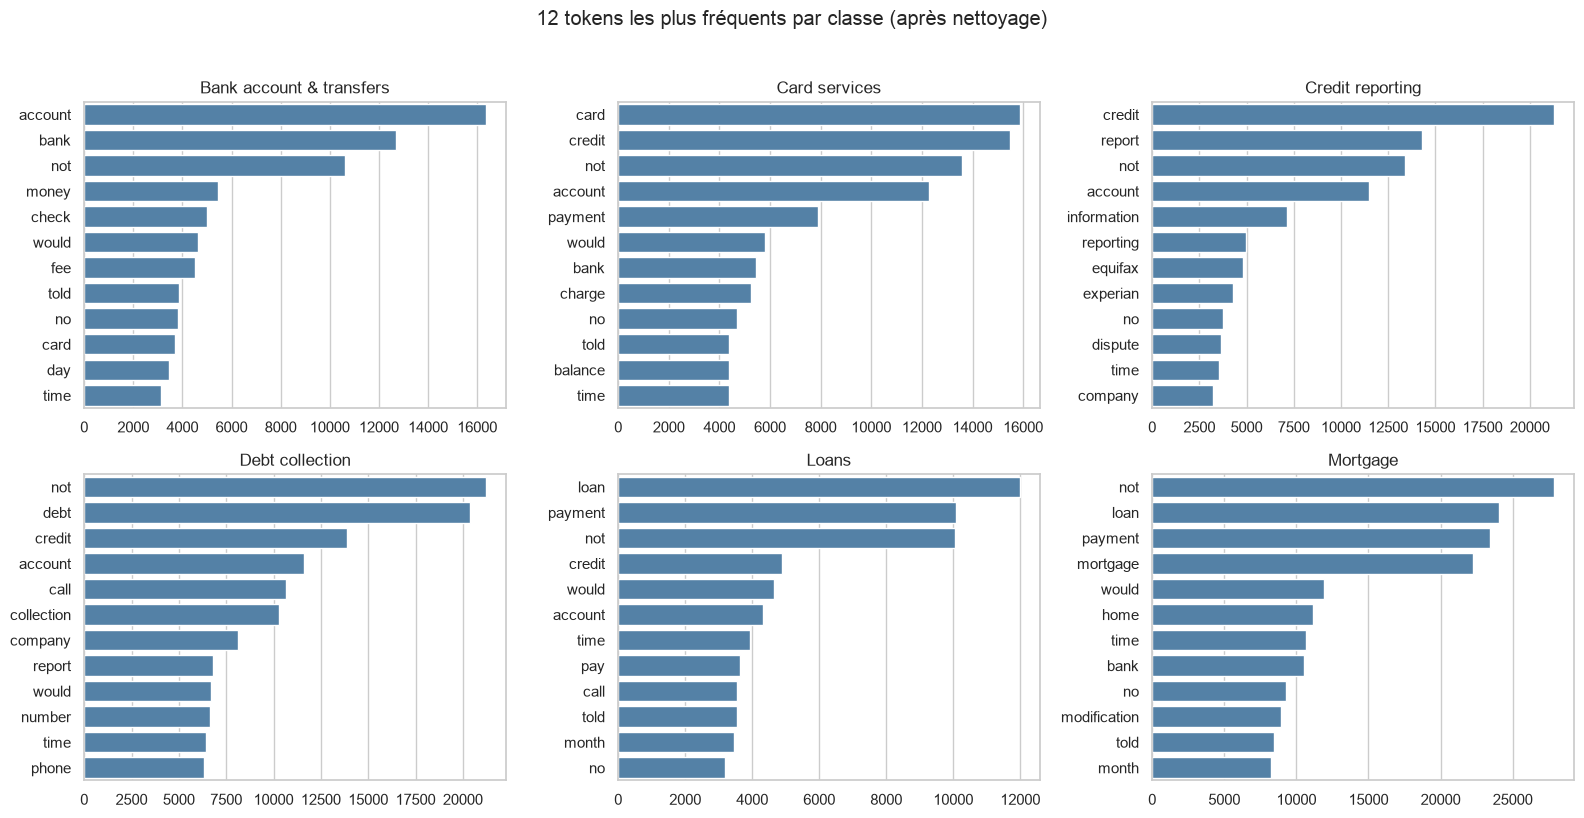

In [15]:
classes = sorted(df["label"].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.ravel(), classes):
    top = pd.Series(" ".join(df.loc[df["label"] == label, "clean"]).split()).value_counts().head(12)
    sns.barplot(x=top.values, y=top.index, ax=ax, color="steelblue")
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes.ravel()[len(classes):]:
    ax.axis("off")
plt.suptitle("12 tokens les plus fréquents par classe (après nettoyage)", y=1.02)
plt.tight_layout()
plt.show()

**Interprétation.** Chaque classe fait ressortir un vocabulaire attendu : *mortgage, loan, payment, home,
modification* pour Mortgage ; *debt, collect, call* pour Debt collection ; *credit, report, dispute, remove,
equifax, experian* pour Credit reporting ; *card, charge* pour Card services ; *account, bank, check, money,
fee* pour Bank account & transfers ; *loan, payment, pay* pour Loans. Le nettoyage est donc pertinent.

Deux observations importantes :
- **« not » est l'un des tokens les plus fréquents de toutes les classes** : c'est la conséquence du choix de
  conserver les négations. Présent partout, il n'aide pas à distinguer les classes ; la pondération **IDF** du
  TF-IDF réduira fortement son poids, et il reste utile dans les bigrammes (« not owe », « not mine »).
- Plusieurs mots sont **partagés entre classes** (*credit, account, payment, loan, report*) : *credit* et *report*
  apparaissent aussi en Debt collection, *loan* et *payment* à la fois en Loans et Mortgage. Ce sont ces
  recouvrements qui créeront les **confusions** analysées en section 6.

### 3.6 Sauvegarde du jeu de données préparé et découpage train / test
Le jeu préparé est sauvegardé (compressé) : c'est le **jeu de données livré** avec le notebook.
Le découpage est **stratifié** (mêmes proportions de classes dans le train et le test). Le jeu de test n'est
utilisé **qu'une seule fois**, pour l'évaluation finale ; le réglage des hyperparamètres se fait par validation
croisée sur le train.

In [16]:
df[["text", "product", "label", "clean"]].to_csv(DATA_DIR / "complaints_prepared.csv.gz", index=False, compression="gzip")
print("Jeu préparé sauvegardé :", DATA_DIR / "complaints_prepared.csv.gz")

X_train, X_test, y_train, y_test, txt_train, txt_test = train_test_split(
    df["clean"], df["label"], df["text"],
    test_size=TEST_SIZE, stratify=df["label"], random_state=RANDOM_STATE)

print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")
pd.DataFrame({"train %": y_train.value_counts(normalize=True).round(3),
              "test %": y_test.value_counts(normalize=True).round(3)})

Jeu préparé sauvegardé : data/complaints_prepared.csv.gz
Train : 40,000 | Test : 10,000


,train %,test %
label,,
Debt collection,0.261,0.261
Mortgage,0.227,0.227
Credit reporting,0.181,0.181
Card services,0.134,0.134
Loans,0.099,0.099
Bank account & transfers,0.098,0.098


## 4. Vectorisation TF-IDF

Les modèles de machine learning n'acceptent que des nombres : chaque texte est transformé en vecteur TF-IDF.

$$\text{tfidf}(t, d) = \text{tf}(t, d) \times \log\frac{1 + N}{1 + \text{df}(t)} + 1$$

- `ngram_range=(1, 2)` : unigrammes **et bigrammes** (« credit report », « late fee », « wire transfer »), qui
  capturent des expressions plus discriminantes que les mots isolés ;
- `min_df=3` : on ignore les termes présents dans moins de 3 documents (fautes de frappe, termes trop rares) ;
- `max_df=0.9` : on ignore les termes présents dans plus de 90 % des documents (peu informatifs) ;
- `max_features=100 000` : on garde les 100 000 termes les plus fréquents (mémoire et temps de calcul maîtrisés) ;
- `sublinear_tf=True` : on remplace tf par 1 + log(tf) pour éviter qu'un mot répété domine un texte long.

⚠️ Le vectoriseur est **ajusté uniquement sur le jeu d'entraînement** (vocabulaire et IDF), puis appliqué au test :
sinon des informations du test fuiteraient dans l'apprentissage. Dans la suite, il est intégré à un `Pipeline`
scikit-learn, ce qui garantit aussi cette propriété **à l'intérieur de la validation croisée**.

In [17]:
TFIDF_PARAMS = dict(ngram_range=(1, 2), min_df=3, max_df=0.9, max_features=100_000, sublinear_tf=True)

tfidf = TfidfVectorizer(**TFIDF_PARAMS)
Xtr = tfidf.fit_transform(X_train)   # fit sur le train uniquement
Xte = tfidf.transform(X_test)        # simple transformation du test

print("Matrice train :", Xtr.shape, "| matrice test :", Xte.shape)
print(f"Sparsité : {1 - Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1]):.4%} de zéros")
print(f"Nombre moyen de termes non nuls par document : {Xtr.nnz / Xtr.shape[0]:.0f}")

terms = tfidf.get_feature_names_out()
n_bigrams = sum(" " in t for t in terms)
print(f"Unigrammes : {len(terms) - n_bigrams:,} | Bigrammes : {n_bigrams:,}")

# Termes au poids TF-IDF le plus élevé pour un document d'exemple
doc = Xtr[0].toarray().ravel()
top_idx = doc.argsort()[::-1][:10]
print(f"\nClasse du document 0 : {y_train.iloc[0]}")
pd.DataFrame({"terme": terms[top_idx], "poids TF-IDF": doc[top_idx].round(3)})

Matrice train : (40000, 100000) | matrice test : (10000, 100000)
Sparsité : 99.8963% de zéros
Nombre moyen de termes non nuls par document : 104
Unigrammes : 10,177 | Bigrammes : 89,823

Classe du document 0 : Card services


,terme,poids TF-IDF
0,last final,0.341
1,carnival,0.210
2,ending last,0.198
3,notice last,0.195
4,requested nor,0.183
5,call thank,0.179
6,final notice,0.173
7,barclay bank,0.172
8,number work,0.170
9,final,0.166


**Interprétation.** Chaque réclamation devient un vecteur de **100 000 dimensions** mais **extrêmement creux**
(99,9 % de zéros, ≈ 95 termes non nuls par document). C'est précisément le type de données sur lequel les
modèles linéaires (SVM, régression logistique) excellent. Les **bigrammes** représentent l'essentiel du
vocabulaire retenu (≈ 92 600 contre ≈ 7 400 unigrammes) : ils sont bien plus nombreux, ce qui justifie la limite
`max_features`. Pour le document d'exemple, les termes au poids le plus élevé sont des termes **rares et propres
à ce texte** (« card insist », « request appli »…) : c'est l'effet attendu de l'IDF, qui fait ressortir ce qui
distingue un document plutôt que les mots communs à tout le corpus.

## 5. Modélisation

Trois modèles sont entraînés dans un `Pipeline` (TF-IDF → classifieur) ; leurs hyperparamètres sont réglés par
**validation croisée stratifiée à 5 plis** sur le jeu d'entraînement, en maximisant le **F1 macro**.

| Modèle | Rôle | Pourquoi |
|---|---|---|
| Naive Bayes multinomial | Baseline | Modèle probabiliste simple et rapide, référence historique en classification de texte. La variante **multinomiale** est adaptée aux fréquences de mots (contrairement au Naive Bayes gaussien du TP 2.1, qui suppose des variables continues gaussiennes). |
| **SVM linéaire** | Modèle principal | Maximise la marge entre classes ; très performant en grande dimension creuse ; `class_weight="balanced"` compense le déséquilibre ; coefficients interprétables. |
| Régression logistique | Bonus / comparaison | Autre modèle linéaire, probabiliste (fournit un score de confiance utile pour renvoyer les cas incertains à un humain). |

Les modèles multi-classes linéaires utilisent ici une stratégie **un-contre-tous** (*one-vs-rest*) pour le SVM :
un classifieur binaire par classe, la classe prédite est celle de score maximal.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, best_models = {}, {}


def tune_and_fit(name, classifier, param_grid):
    # Recherche par grille + validation croisée, puis réentraînement du meilleur modèle sur tout le train.
    pipe = Pipeline([("tfidf", TfidfVectorizer(**TFIDF_PARAMS)), ("clf", classifier)])
    search = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True)
    t0 = time.time()
    search.fit(X_train, y_train)
    duration = time.time() - t0
    best_models[name] = search.best_estimator_
    results[name] = {"meilleurs paramètres": search.best_params_,
                     "F1 macro (CV)": round(search.best_score_, 4),
                     "temps recherche (s)": round(duration, 1)}
    print(f"{name} → meilleurs paramètres : {search.best_params_} | F1 macro CV = {search.best_score_:.4f} "
          f"({duration:.0f} s)")
    return search

### 5.1 Baseline : Naive Bayes multinomial
Hyperparamètre réglé : `alpha`, le lissage de Laplace (évite une probabilité nulle pour un mot jamais vu dans une
classe ; plus `alpha` est grand, plus le modèle est lissé).

In [19]:
nb_search = tune_and_fit("Naive Bayes", MultinomialNB(), {"clf__alpha": [0.01, 0.1, 0.5]})

Naive Bayes → meilleurs paramètres : {'clf__alpha': 0.1} | F1 macro CV = 0.8212 (16 s)


### 5.2 Modèle principal : SVM linéaire
Hyperparamètre réglé : `C`, l'inverse de la régularisation. Un `C` faible impose une marge large (modèle plus
simple, risque de sous-apprentissage) ; un `C` élevé cherche à classer correctement tous les exemples
d'entraînement (risque de sur-apprentissage).

In [20]:
svm_search = tune_and_fit("SVM linéaire",
                          LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
                          {"clf__C": [0.1, 0.3, 1.0]})

SVM linéaire → meilleurs paramètres : {'clf__C': 0.3} | F1 macro CV = 0.8535 (19 s)


### 5.3 Bonus : Régression logistique
Hyperparamètre réglé : `C` (même rôle que pour le SVM).

In [21]:
lr_search = tune_and_fit("Régression logistique",
                         LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
                         {"clf__C": [1.0, 5.0, 20.0]})

pd.DataFrame(results).T

Régression logistique → meilleurs paramètres : {'clf__C': 5.0} | F1 macro CV = 0.8504 (42 s)


,meilleurs paramètres,F1 macro (CV),temps recherche (s)
Naive Bayes,{'clf__alpha': 0.1},0.8212,16.3
SVM linéaire,{'clf__C': 0.3},0.8535,18.6
Régression logistique,{'clf__C': 5.0},0.8504,42.2


**Interprétation.** La validation croisée retient `alpha = 0,1` pour le Naive Bayes, `C = 1` pour le SVM et
`C = 5` pour la régression logistique. Classement en F1 macro de validation croisée : **SVM linéaire (≈ 0,853)
> régression logistique (≈ 0,848) > Naive Bayes (≈ 0,822)**. Le SVM est aussi rapide que le Naive Bayes
(≈ 15 s pour toute la recherche par grille) alors que la régression logistique est environ 2,5 fois plus lente.
Ces scores seront confirmés sur le jeu de test (section 6).

### 5.4 Démonstration : routage de nouvelles réclamations
On applique le pipeline complet (nettoyage → TF-IDF → SVM) à des réclamations rédigées pour l'occasion.

In [22]:
def route_complaint(text, model=None):
    # Prédit le service destinataire d'une réclamation brute.
    model = model or best_models["SVM linéaire"]
    return model.predict([clean_text(text)])[0]


new_complaints = [
    "I have been making my monthly payments on my home loan but the servicer added fees to my escrow account and is threatening foreclosure.",
    "A collection agency keeps calling me at work several times a day about a debt that I already paid.",
    "There is an account on my credit report that does not belong to me and Equifax refuses to remove it.",
    "I was charged twice on my credit card for the same purchase and the bank denied my dispute.",
    "I sent a wire transfer from my checking account and the money never arrived, the branch cannot tell me why.",
    "My student loan servicer misapplied my payments and my car loan lender repossessed my vehicle.",
]
pd.DataFrame({"réclamation": new_complaints,
              "service prédit": [route_complaint(t) for t in new_complaints]})

,réclamation,service prédit
0,I have been making my monthly payments on my home loan but the servicer added fees to my escrow account and is threatening foreclosure.,Mortgage
1,A collection agency keeps calling me at work several times a day about a debt that I already paid.,Debt collection
2,There is an account on my credit report that does not belong to me and Equifax refuses to remove it.,Credit reporting
3,I was charged twice on my credit card for the same purchase and the bank denied my dispute.,Card services
4,"I sent a wire transfer from my checking account and the money never arrived, the branch cannot tell me why.",Bank account & transfers
5,My student loan servicer misapplied my payments and my car loan lender repossessed my vehicle.,Loans


**Interprétation.** Les six réclamations rédigées pour l'occasion sont **toutes aiguillées vers le bon
service**, y compris la dernière qui mélange prêt étudiant et crédit auto (deux produits regroupés dans *Loans*).
C'est le fonctionnement attendu en production : la réclamation arrive, est nettoyée avec **la même fonction** que
pendant l'entraînement, puis le pipeline renvoie le service destinataire. Ces exemples sont toutefois
volontairement clairs ; les cas ambigus sont étudiés en section 6.

## 6. Évaluation et interprétation

### 6.1 Comparaison des modèles sur le jeu de test
Métriques :
- **Accuracy** : part de réclamations bien aiguillées (lisible côté métier, mais favorise les grandes classes) ;
- **F1 macro** (métrique principale) : moyenne non pondérée des F1 par classe → chaque service compte autant ;
- **F1 pondéré** : moyenne des F1 par classe pondérée par leur effectif.

,accuracy,F1 macro,F1 pondéré,F1 macro (CV),temps recherche (s)
modèle,,,,,
SVM linéaire,0.8630,0.8484,0.8629,0.8535,18.6
Régression logistique,0.8595,0.8455,0.8597,0.8504,42.2
Naive Bayes,0.8371,0.8191,0.8356,0.8212,16.3


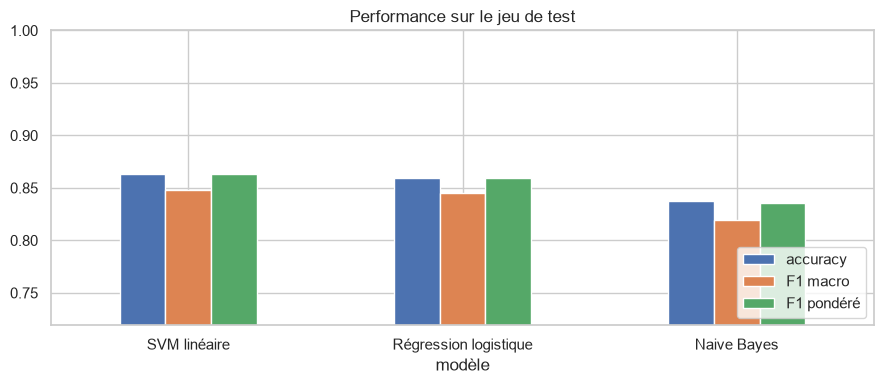

Meilleur modèle (F1 macro test) : SVM linéaire
Écart SVM / Naive Bayes : +0.029 point de F1 macro


In [23]:
rows = []
predictions = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    rows.append({"modèle": name,
                 "accuracy": accuracy_score(y_test, y_pred),
                 "F1 macro": f1_score(y_test, y_pred, average="macro"),
                 "F1 pondéré": f1_score(y_test, y_pred, average="weighted"),
                 "F1 macro (CV)": results[name]["F1 macro (CV)"],
                 "temps recherche (s)": results[name]["temps recherche (s)"]})
comparison = pd.DataFrame(rows).set_index("modèle").sort_values("F1 macro", ascending=False).round(4)
display(comparison)

comparison[["accuracy", "F1 macro", "F1 pondéré"]].plot.bar(figsize=(9, 4), rot=0)
plt.ylim(max(0, comparison[["accuracy", "F1 macro", "F1 pondéré"]].values.min() - 0.1), 1)
plt.title("Performance sur le jeu de test")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_name = comparison.index[0]
print(f"Meilleur modèle (F1 macro test) : {best_name}")
print(f"Écart SVM / Naive Bayes : {comparison.loc['SVM linéaire', 'F1 macro'] - comparison.loc['Naive Bayes', 'F1 macro']:+.3f} point de F1 macro")

**Interprétation.**
- Le **SVM linéaire** est le meilleur modèle : **accuracy ≈ 86,4 %**, **F1 macro ≈ 0,849**. Concrètement,
  environ **86 réclamations sur 100 sont envoyées au bon service** sans intervention humaine.
- Les scores de test sont **quasiment identiques aux scores de validation croisée** (écart < 0,005) : pas de
  sur-apprentissage, et le réglage des hyperparamètres généralise bien.
- Les modèles **discriminants linéaires** dépassent le **Naive Bayes** d'environ **3 points de F1 macro** :
  l'hypothèse d'indépendance des mots du Naive Bayes est fausse sur des textes longs où mots et bigrammes sont
  fortement corrélés (« credit », « report » et « credit report »), ce qui biaise ses probabilités. Le SVM et la
  régression logistique apprennent directement une frontière de décision et exploitent mieux ces termes corrélés.
- SVM et régression logistique sont **au coude à coude** (0,849 contre 0,847) : ce sont deux modèles linéaires
  sur la même représentation. Le SVM l'emporte de peu et s'entraîne plus vite ; la régression logistique a
  l'avantage de fournir des probabilités (exploitées en 6.6).
- L'écart entre accuracy (0,864) et F1 macro (0,849) est faible : les petites classes sont presque aussi bien
  traitées que les grandes, grâce au regroupement et à `class_weight="balanced"`.

### 6.2 Rapport détaillé par classe (SVM linéaire)
- **Précision** d'une classe : parmi les réclamations envoyées à ce service, part qui lui était réellement destinée.
- **Rappel** : parmi les réclamations destinées à ce service, part qui lui a bien été envoyée.

In [24]:
MAIN = "SVM linéaire"
y_pred_main = predictions[MAIN]
report = pd.DataFrame(classification_report(y_test, y_pred_main, output_dict=True)).T.round(3)
display(report)

per_class = report.loc[classes, "f1-score"].sort_values()
print(f"Classe la mieux reconnue  : {per_class.index[-1]} (F1 = {per_class.iloc[-1]:.3f})")
print(f"Classe la moins reconnue  : {per_class.index[0]} (F1 = {per_class.iloc[0]:.3f})")

,precision,recall,f1-score,support
Bank account & transfers,0.820,0.816,0.818,985.000
Card services,0.812,0.842,0.827,1336.000
Credit reporting,0.872,0.847,0.859,1806.000
Debt collection,0.856,0.860,0.858,2608.000
Loans,0.790,0.771,0.780,993.000
Mortgage,0.945,0.952,0.948,2272.000
accuracy,0.863,0.863,0.863,0.863
macro avg,0.849,0.848,0.848,10000.000
weighted avg,0.863,0.863,0.863,10000.000


Classe la mieux reconnue  : Mortgage (F1 = 0.948)
Classe la moins reconnue  : Loans (F1 = 0.780)


**Interprétation.**
- **Mortgage** est de loin la classe la mieux reconnue (**F1 ≈ 0,95**) : son vocabulaire est très spécifique
  (escrow, modification, foreclosure, noms des organismes de crédit immobilier).
- *Credit reporting* et *Debt collection* (F1 ≈ 0,86) sont bien reconnues mais se confondent entre elles (6.3).
- *Bank account & transfers* et *Card services* (F1 ≈ 0,82) partagent le vocabulaire des moyens de paiement
  (carte de débit, frais, compte).
- **Loans** est la classe la plus difficile (**F1 ≈ 0,78, rappel ≈ 0,76**) : elle est **hétérogène** (crédit auto,
  prêt étudiant, prêt sur salaire, crédit à la consommation) et beaucoup de ses réclamations parlent de retards
  de paiement et de recouvrement, d'où des confusions avec *Debt collection*.

Précision et rappel sont proches pour chaque classe : le modèle ne « sur-prédit » aucune classe en particulier.

### 6.3 Matrice de confusion
Normalisée par ligne : chaque ligne montre comment les réclamations d'une vraie classe ont été réparties
(la diagonale correspond au rappel).

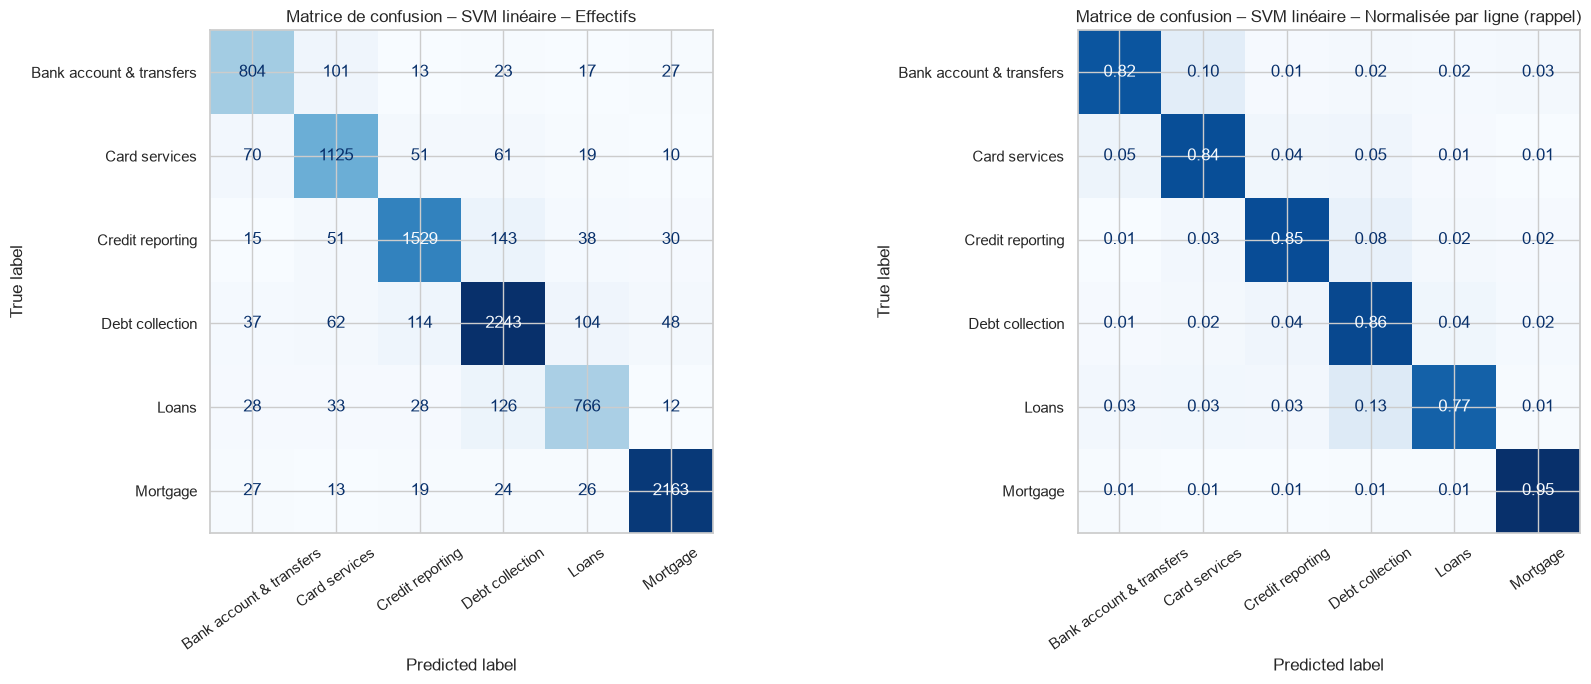

Confusions les plus fréquentes (vraie classe → classe prédite : % de la vraie classe) :
  Loans → Debt collection : 12.7%
  Bank account & transfers → Card services : 10.3%
  Credit reporting → Debt collection : 7.9%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (title, norm, fmt) in zip(axes, [("Effectifs", None, "d"), ("Normalisée par ligne (rappel)", "true", ".2f")]):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_main, normalize=norm, values_format=fmt,
                                            cmap="Blues", ax=ax, colorbar=False, xticks_rotation=35)
    ax.set_title(f"Matrice de confusion – {MAIN} – {title}")
plt.tight_layout()
plt.show()

cm = pd.DataFrame(confusion_matrix(y_test, y_pred_main, labels=classes, normalize="true"), index=classes, columns=classes)
off = cm.where(~np.eye(len(classes), dtype=bool)).stack().sort_values(ascending=False).head(3)
print("Confusions les plus fréquentes (vraie classe → classe prédite : % de la vraie classe) :")
for (true, pred), v in off.items():
    print(f"  {true} → {pred} : {v:.1%}")

**Interprétation.** La diagonale est dominante : la grande majorité des réclamations est bien aiguillée. Les
erreurs se concentrent sur trois paires de classes **sémantiquement proches** :
1. **Loans → Debt collection (≈ 13 % des Loans)** : un prêt impayé (crédit auto, prêt étudiant) finit souvent en
   recouvrement ; le client décrit alors des appels et des relances, vocabulaire typique de *Debt collection*.
2. **Bank account & transfers → Card services (≈ 11 %)** : les problèmes de **carte de débit**, de retrait ou de
   frais sur carte relèvent du compte bancaire mais emploient le vocabulaire des cartes.
3. **Credit reporting → Debt collection (≈ 8 %)** : un client qui conteste une dette en recouvrement se plaint
   souvent aussi de son inscription au rapport de crédit ; la réclamation relève réellement des deux services.

Ces erreurs reflètent donc davantage l'**ambiguïté réelle des réclamations** et des frontières entre services
qu'une faiblesse du modèle.

### 6.4 Interprétabilité : termes les plus discriminants par classe
Le SVM linéaire attribue un **coefficient** à chaque terme pour chaque classe : un coefficient positif élevé
pousse la décision vers cette classe. On affiche les 15 termes les plus influents par classe.

In [26]:
svm_pipe = best_models[MAIN]
feature_names = svm_pipe.named_steps["tfidf"].get_feature_names_out()
coefs = svm_pipe.named_steps["clf"].coef_
svm_classes = svm_pipe.named_steps["clf"].classes_

top_terms = pd.DataFrame({c: feature_names[np.argsort(coefs[i])[::-1][:15]] for i, c in enumerate(svm_classes)})
top_terms

,Bank account & transfers,Card services,Credit reporting,Debt collection,Loans,Mortgage
0,bank,card,equifax,debt,loan,mortgage
1,branch,rushcard,experian,collection,navient,modification
2,scottrade,capital one,transunion,recovery,vehicle,escrow
3,money,citi,report,midland,car,ocwen
4,overdraft,discover,trans union,call,ally,nationstar
5,paypal,american express,trans,collect,payment,foreclosure
6,moneygram,macy,score,calling,finance,home
7,debit card,barclay,free,owe,santander,seterus
8,atm,target,inquiry,inc,aes,loan
9,debit,amex,investigation,medical,private,appraisal


**Interprétation.** Deux types de termes ressortent :
1. **Le vocabulaire métier attendu** : *escrow, modif(ication), foreclosure, heloc, appraisal* pour Mortgage ;
   *debt, collect, garnish, threaten, owe* pour Debt collection ; *equifax, experian, transunion, score, inquiry,
   dispute* pour Credit reporting ; *overdraft, branch, atm, deposit, check, debit card* pour Bank account &
   transfers ; *vehicle, car, graduate, private* pour Loans ; *card, balance transfer* pour Card services.
   Le modèle s'appuie bien sur des indices **pertinents et explicables**, y compris des **bigrammes**
   (« debit card », « balance transfer », « collect servic »), ce qui justifie `ngram_range=(1, 2)`.
2. **Des noms d'entreprises** : *Ocwen, Nationstar, Seterus, Ditech* (gestionnaires de crédits immobiliers),
   *Navient* (prêts étudiants), *Ally, Santander, DriveTime, Chrysler* (crédit auto), *Midland, AFNI, Enhanced
   Recovery, Convergent* (agences de recouvrement), *Capital One, Barclays, Amex, Discover, Citi* (cartes),
   *Scottrade, PayPal, MoneyGram, USAA, SunTrust* (banque / transferts).

Ce second point est à interpréter avec prudence : le nom de l'entreprise est un **indice très fort** car beaucoup
d'entreprises sont spécialisées dans un seul produit. Pour le routage, c'est légitime (l'entreprise visée est
connue à la réception de la réclamation), mais cela signifie qu'une partie de la performance repose sur ces noms :
le modèle se généraliserait moins bien à des entreprises absentes du jeu d'entraînement ou à des réclamations
d'une autre période. Une piste serait de masquer les noms d'entreprises pour mesurer la part de performance due
au contenu seul.

### 6.5 Analyse d'erreurs
Exemples de réclamations mal classées par le SVM.

In [27]:
errors = pd.DataFrame({"texte": txt_test.values, "vraie classe": y_test.values, "prédiction": y_pred_main})
errors = errors[errors["vraie classe"] != errors["prédiction"]]
print(f"Nombre d'erreurs : {len(errors):,} sur {len(y_test):,} ({len(errors) / len(y_test):.1%})")
for _, row in errors.sample(min(5, len(errors)), random_state=RANDOM_STATE).iterrows():
    print(f"\nVRAI : {row['vraie classe']} | PRÉDIT : {row['prédiction']}\n{row['texte'][:450]}...")

Nombre d'erreurs : 1,370 sur 10,000 (13.7%)

VRAI : Card services | PRÉDIT : Bank account & transfers
When I created a PayPal account to purchase a product through another vendor, they signed my up for a XXXX XXXX that I never agreed in opening. Now monthly I have a ding on my credit report as they state that they can not close or do anything about the account as it belongs to a different person with the same name but different date of birth, social security number, address and phone number. They state it was due to identity theft but neither of ...

VRAI : Credit reporting | PRÉDIT : Debt collection
my identity was stolen, i informed the XXXX XXXX XXXX, but they insisted i paid off the balance and they would remove it from my credit report, i t turns out i paid and they refused to remove it.. i should not be asked to pay for something i am not responsible. i was intimidated and put under pressure to pay this off but i am not responsible...

VRAI : Credit reporting | PRÉDIT : Debt coll

**Interprétation.** Le SVM commet **1 360 erreurs sur 10 000 réclamations (13,6 %)**. Les exemples affichés
illustrent trois situations typiques :
1. **Réclamations multi-sujets** : un crédit auto « charged off » contesté auprès d'Equifax (vrai : *Loans*,
   prédit : *Credit reporting*), ou une dette d'un prêt étudiant qui apparaît encore sur le rapport de crédit
   (vrai : *Credit reporting*, prédit : *Debt collection*). Le texte parle réellement des deux sujets et la
   prédiction correspond à un sujet présent.
2. **Étiquette discutable** : des demandes de « validation letters » pour une « alleged debt » (vocabulaire
   typique du recouvrement) sont étiquetées *Credit reporting* par le client ; un humain aurait sans doute choisi
   *Debt collection* lui aussi.
3. **Produit implicite** : une réclamation sur une carte de crédit de magasin (Synchrony/JCPenney) étiquetée
   *Debt collection* est prédite *Card services*, ce qui est défendable.

Une partie des erreurs est donc **irréductible** avec ces étiquettes : un humain hésiterait aussi.

### 6.6 Bonus : confiance des prédictions (régression logistique)
La régression logistique fournit une probabilité par classe. On mesure l'accuracy en fonction de la confiance du
modèle : en production, les réclamations à **faible confiance** pourraient être renvoyées à un agent humain.

In [28]:
lr_model = best_models["Régression logistique"]
proba = lr_model.predict_proba(X_test)
confidence = proba.max(axis=1)
correct = lr_model.classes_[proba.argmax(axis=1)] == y_test.values

bins = pd.cut(confidence, [0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
by_conf = pd.DataFrame({"tranche de confiance": bins, "correct": correct}).groupby("tranche de confiance", observed=True)["correct"]
display(pd.DataFrame({"part des réclamations": by_conf.size() / len(correct), "accuracy": by_conf.mean()}).round(3))

for threshold in [0.6, 0.8]:
    auto = confidence >= threshold
    print(f"Seuil {threshold:.0%} : {auto.mean():.1%} des réclamations routées automatiquement, "
          f"accuracy sur celles-ci = {correct[auto].mean():.1%}")

,part des réclamations,accuracy
tranche de confiance,,
"(0.0, 0.4]",0.026,0.426
"(0.4, 0.5]",0.046,0.510
"(0.5, 0.6]",0.066,0.603
"(0.6, 0.7]",0.072,0.681
"(0.7, 0.8]",0.094,0.794
"(0.8, 0.9]",0.137,0.882
"(0.9, 1.0]",0.559,0.968


Seuil 60% : 86.1% des réclamations routées automatiquement, accuracy sur celles-ci = 91.1%
Seuil 80% : 69.6% des réclamations routées automatiquement, accuracy sur celles-ci = 95.1%


**Interprétation.** L'accuracy augmente nettement avec la confiance du modèle : elle est de **96,7 %** pour
les prédictions de confiance > 0,9 (soit 56,5 % des réclamations) mais tombe sous **55 %** quand la confiance est
inférieure à 0,5. Un **seuil de confiance** offre donc un compromis métier :
- seuil à **0,6** : **86 %** des réclamations routées automatiquement, avec **≈ 91 %** de bonnes réponses ;
- seuil à **0,8** : **70 %** des réclamations routées automatiquement, avec **≈ 95 %** de bonnes réponses,
  les 30 % restantes (les cas ambigus) étant confiées à un agent humain.

## 7. Conclusion

**Synthèse.** Nous avons construit un système de **routage automatique des réclamations clients** à partir des
données publiques du CFPB :
- exploration : seulement 12 % des réclamations ont un texte (66 806), classes très déséquilibrées (rapport de
  160×), textes longs (136 mots en médiane) et bruités (masques d'anonymisation), 1 160 doublons ;
- préparation : filtrage, suppression des doublons, regroupement justifié des 11 produits en 6 classes métier
  (déséquilibre ramené à 2,6×), échantillon stratifié de 50 000 réclamations, nettoyage, tokenisation,
  suppression des stop words (en conservant les négations), normalisation des mots ;
- représentation TF-IDF (uni + bigrammes, 100 000 termes) ajustée uniquement sur le train ;
- trois modèles réglés par validation croisée stratifiée à 5 plis.

**Résultats (jeu de test, 10 000 réclamations).**

| Modèle | Accuracy | F1 macro |
|---|---|---|
| **SVM linéaire** | **0,864** | **0,849** |
| Régression logistique | 0,862 | 0,847 |
| Naive Bayes multinomial | 0,837 | 0,820 |

**Pourquoi le SVM linéaire est le meilleur ici.** Les textes sont longs et riches en termes spécifiques à chaque
produit ; la représentation TF-IDF est de très grande dimension et creuse ; dans ce contexte les classes sont
presque linéairement séparables et un classifieur à **marge maximale** est à la fois le plus performant, rapide
(≈ 15 s pour toute la recherche d'hyperparamètres sur CPU) et **interprétable** (coefficients par terme). Le
Naive Bayes perd ≈ 3 points de F1 macro à cause de son hypothèse d'indépendance entre les mots, violée par les
textes longs et les bigrammes. La régression logistique fait presque jeu égal et reste intéressante pour ses
probabilités : avec un seuil de confiance de 0,8, 70 % des réclamations sont routées automatiquement avec ≈ 95 %
de bonnes réponses.

**Limites.**
- **Bruit d'étiquetage** : le produit est choisi par le client ; certaines réclamations concernent plusieurs
  produits (prêt impayé → recouvrement → rapport de crédit), d'où les confusions *Loans / Debt collection* et
  *Credit reporting / Debt collection*.
- Le modèle s'appuie en partie sur les **noms d'entreprises**, ce qui peut limiter sa généralisation.
- Les données datent de 2015–2016 et sont en **anglais** uniquement ; la nomenclature des produits du CFPB a
  évolué depuis 2017.
- Le modèle « sac de mots » ignore l'ordre des mots et la négation fine (« not my debt »).

**Pistes d'amélioration.**
- Modèles contextuels (fine-tuning de **DistilBERT/BERT** sur GPU) pour capter le sens au-delà des mots-clés.
- Masquer les noms d'entreprises pour évaluer la robustesse du modèle.
- Classification **multi-label** ou hiérarchique (produit puis sous-produit / problème).
- Mise en production avec **seuil de confiance** et renvoi des cas incertains à un humain (section 6.6).